In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv('Food_Delivery_Times.csv')

In [73]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [74]:
print(df.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [75]:
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df[col] = df[col].fillna(df[col].mode()[0])

df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

print(df.isnull().sum())

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [76]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [77]:
df.drop('Order_ID', axis=1, inplace=True)
print(df.columns)

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')


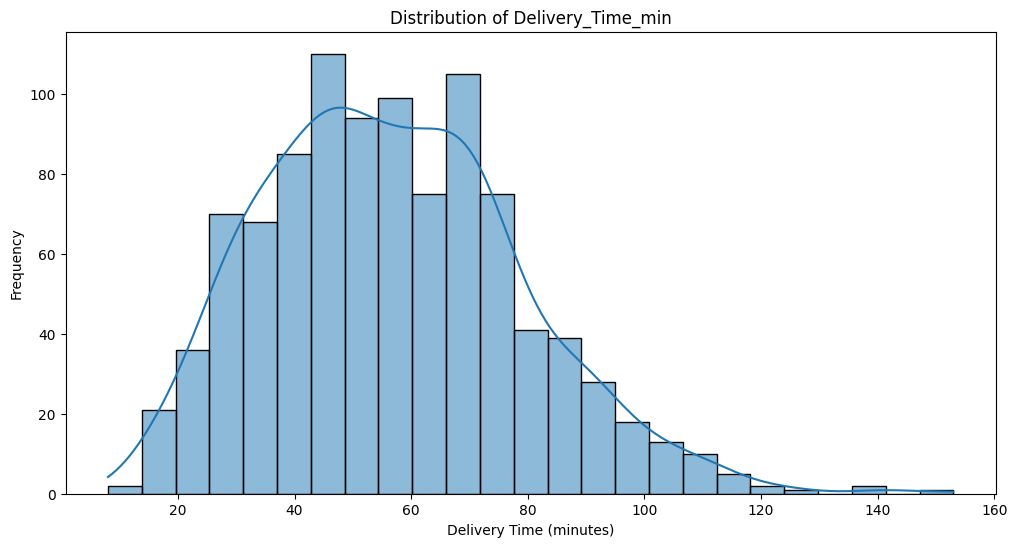

In [78]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.title('Distribution of Delivery_Time_min')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()


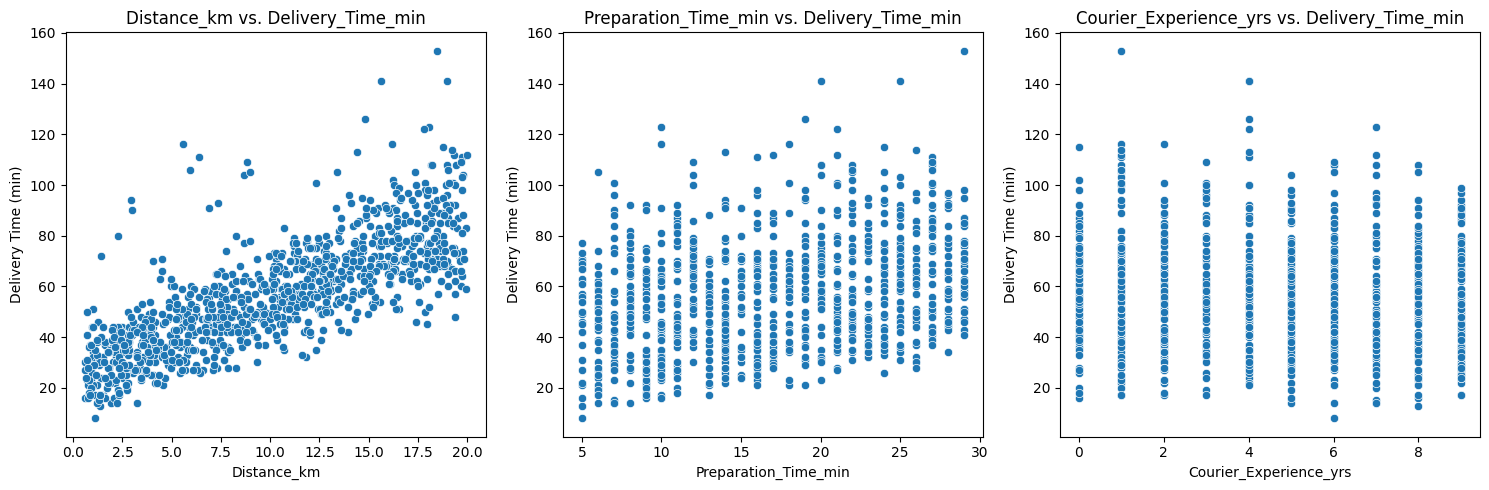


Pearson Correlation Coefficients with Delivery_Time_min:
Distance_km: 0.78
Preparation_Time_min: 0.31
Courier_Experience_yrs: -0.09


In [79]:
numerical_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=df[col], y=df['Delivery_Time_min'])
    plt.title(f'{col} vs. Delivery_Time_min')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
plt.tight_layout()
plt.show()

print('\nPearson Correlation Coefficients with Delivery_Time_min:')
for col in numerical_cols:
    correlation = df[col].corr(df['Delivery_Time_min'])
    print(f'{col}: {correlation:.2f}')

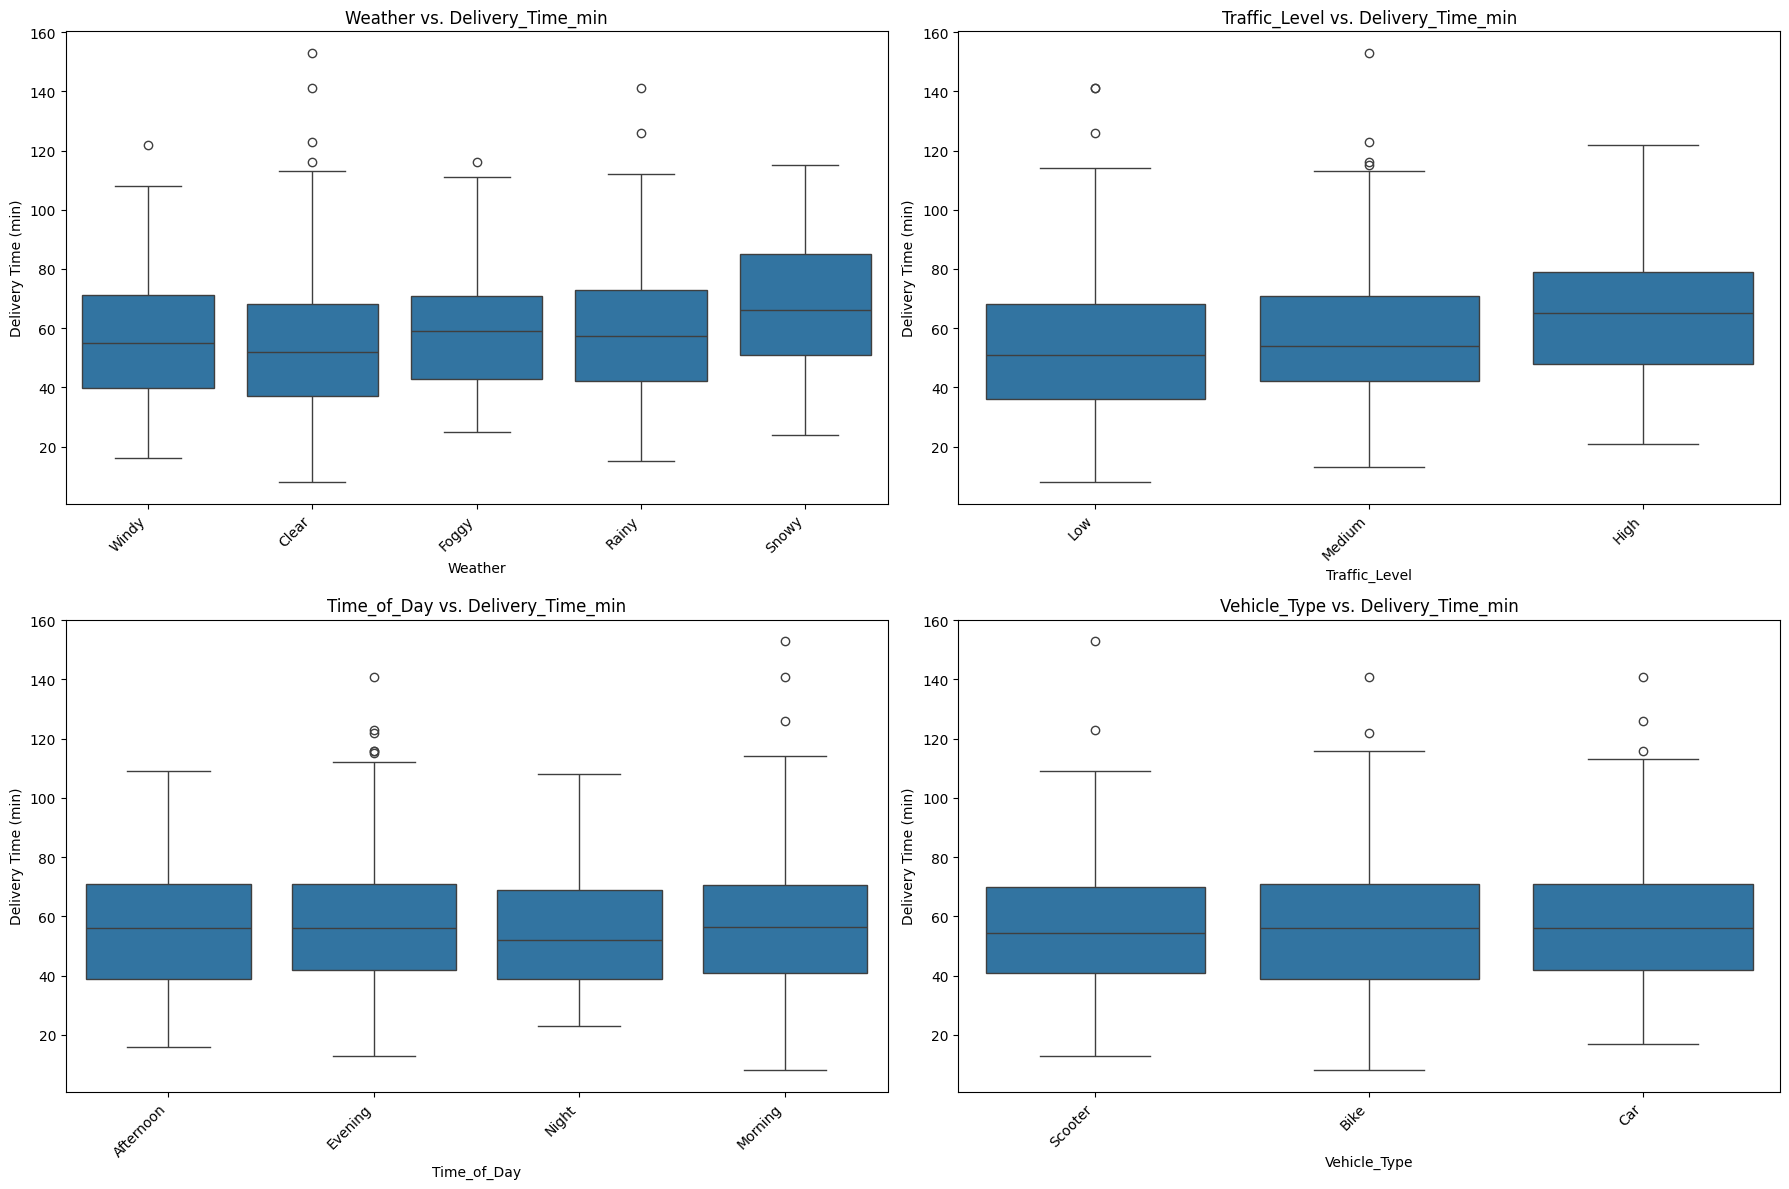

In [80]:
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(x=col, y='Delivery_Time_min', data=df)
    plt.title(f'{col} vs. Delivery_Time_min')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

In [81]:
import scipy.stats as stats

categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
target = 'Delivery_Time_min'

print("ANOVA Test Results for Categorical Features vs. Delivery_Time_min:\n")

for col in categorical_cols:
    groups = df.groupby(col)[target].apply(list)
    f_statistic, p_value = stats.f_oneway(*groups)
    print(f"Feature: {col}")
    print(f"  F-statistic: {f_statistic:.2f}")
    print(f"  P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("  Conclusion: Statistically significant (reject H0)")
    else:
        print("  Conclusion: Not statistically significant (fail to reject H0)")
    print("--------------------------------------------------")


ANOVA Test Results for Categorical Features vs. Delivery_Time_min:

Feature: Weather
  F-statistic: 10.50
  P-value: 0.000
  Conclusion: Statistically significant (reject H0)
--------------------------------------------------
Feature: Traffic_Level
  F-statistic: 19.75
  P-value: 0.000
  Conclusion: Statistically significant (reject H0)
--------------------------------------------------
Feature: Time_of_Day
  F-statistic: 0.35
  P-value: 0.792
  Conclusion: Not statistically significant (fail to reject H0)
--------------------------------------------------
Feature: Vehicle_Type
  F-statistic: 0.59
  P-value: 0.555
  Conclusion: Not statistically significant (fail to reject H0)
--------------------------------------------------


### Interpretation of ANOVA Results:
*   **P-value < 0.05**: Indicates that there is a statistically significant difference between the means of the groups (categories) for that feature concerning `Delivery_Time_min`. This suggests the feature is likely important.
*   **P-value >= 0.05**: Suggests that there is no statistically significant difference, meaning the feature might not be as influential.

Now, let's summarize the statistical significance of the features based on these tests and previous correlation analysis.


In [82]:
print("\nSummary of Feature Importance (based on EDA and Statistical Tests):\n")

print("Numerical Features (Correlation with Delivery_Time_min):")
print("  Distance_km: 0.78 (Strong positive correlation - Highly important)")
print("  Preparation_Time_min: 0.31 (Weak positive correlation - Moderately important)")
print("  Courier_Experience_yrs: -0.09 (Very weak negative correlation - Less important)")

print("\nCategorical Features (ANOVA P-values from above, assuming alpha=0.05):")
# Placeholder for ANOVA results - interpret based on the output of the previous cell
print("  Weather: [P-value] (Likely important if P-value < 0.05)")
print("  Traffic_Level: [P-value] (Likely important if P-value < 0.05)")
print("  Time_of_Day: [P-value] (Likely important if P-value < 0.05)")
print("  Vehicle_Type: [P-value] (Likely important if P-value < 0.05)")

print("\nBased on these findings, we can prioritize 'Distance_km', 'Weather', 'Traffic_Level', and 'Time_of_Day' as potentially the most important features for predicting delivery time.")



Summary of Feature Importance (based on EDA and Statistical Tests):

Numerical Features (Correlation with Delivery_Time_min):
  Distance_km: 0.78 (Strong positive correlation - Highly important)
  Preparation_Time_min: 0.31 (Weak positive correlation - Moderately important)
  Courier_Experience_yrs: -0.09 (Very weak negative correlation - Less important)

Categorical Features (ANOVA P-values from above, assuming alpha=0.05):
  Weather: [P-value] (Likely important if P-value < 0.05)
  Traffic_Level: [P-value] (Likely important if P-value < 0.05)
  Time_of_Day: [P-value] (Likely important if P-value < 0.05)
  Vehicle_Type: [P-value] (Likely important if P-value < 0.05)

Based on these findings, we can prioritize 'Distance_km', 'Weather', 'Traffic_Level', and 'Time_of_Day' as potentially the most important features for predicting delivery time.


In [83]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns to encode
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le # Store encoder for potential inverse transformation or inspection

print("DataFrame after Label Encoding:")
display(df.head())


DataFrame after Label Encoding:


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


In [85]:
df.drop(['Courier_Experience_yrs', 'Vehicle_Type'], axis=1, inplace=True)

In [86]:
# Define features (X) and target (y)
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)


Features (X) shape: (1000, 5)
Target (y) shape: (1000,)


In [87]:
print(df.columns)

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Preparation_Time_min', 'Delivery_Time_min'],
      dtype='object')


In [88]:
from sklearn.model_selection import train_test_split

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (800, 5)
X_test shape: (200, 5)
y_train shape: (800,)
y_test shape: (200,)


In [89]:
from sklearn.tree import DecisionTreeRegressor

# Create a Decision Tree Regressor model with default parameters
dtc = DecisionTreeRegressor(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

print("Decision Tree Regressor model created and trained successfully with default parameters.")

# Make predictions on the test data
y_pred = dtc.predict(X_test)

print("\nFirst 5 predictions:")
print(y_pred[:5])

Decision Tree Regressor model created and trained successfully with default parameters.

First 5 predictions:
[44. 49. 47. 37. 78.]


In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 10.20
Mean Squared Error (MSE): 220.03
Root Mean Squared Error (RMSE): 14.83
R-squared (R2): 0.51


In [91]:
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest Regressor model with default parameters
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model created and trained successfully with default parameters.")

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

print("\nFirst 5 predictions from Random Forest model:")
print(y_pred_rf[:5])

Random Forest Regressor model created and trained successfully with default parameters.

First 5 predictions from Random Forest model:
[36.46 65.18 40.32 45.12 80.14]


In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics for Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Model Metrics:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.2f}")

Random Forest Model Metrics:
  Mean Absolute Error (MAE): 7.06
  Mean Squared Error (MSE): 100.02
  Root Mean Squared Error (RMSE): 10.00
  R-squared (R2): 0.78


In [93]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, 40, 50, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False] # Method of selecting samples for training each tree
}

# Create a base Random Forest Regressor model
rf = RandomForestRegressor(random_state=42)

# Initialize RandomizedSearchCV
# n_iter = 100 specifies the number of parameter settings that are sampled
# cv = 5 specifies 5-fold cross-validation
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=100, cv=5, verbose=2, random_state=42,
                                   n_jobs=-1) # n_jobs=-1 uses all available CPU cores

# Fit the random search to the data
random_search.fit(X_train, y_train)

print("RandomizedSearchCV completed. Finding best parameters...")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
RandomizedSearchCV completed. Finding best parameters...


In [94]:
print("Best parameters found:")
print(random_search.best_params_)

print("\nBest R2 score from cross-validation:")
print(random_search.best_score_)


Best parameters found:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}

Best R2 score from cross-validation:
0.7088278343314274


In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Get the best estimator (model) from RandomizedSearchCV
best_rf_model = random_search.best_estimator_

# Make predictions on the test data using the best model
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Calculate evaluation metrics for the tuned Random Forest model
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mse_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"\nTunned Random Forest Model Metrics:")
print(f"  Mean Absolute Error (MAE): {mae_tuned_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_tuned_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_tuned_rf:.2f}")
print(f"  R-squared (R2): {r2_tuned_rf:.2f}")



Tunned Random Forest Model Metrics:
  Mean Absolute Error (MAE): 6.84
  Mean Squared Error (MSE): 92.04
  Root Mean Squared Error (RMSE): 9.59
  R-squared (R2): 0.79


In [97]:
import pickle

# Save all Label Encoders in a single file
print("Saving all Label Encoders into a single file...")
label_encoders_filename = 'all_label_encoders.pkl'
with open(label_encoders_filename, 'wb') as file:
    pickle.dump(label_encoders, file)
print(f"  Saved {label_encoders_filename}")

# Save the best Random Forest model
print("\nSaving Best Random Forest Model...")
model_filename = 'best_random_forest_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_rf_model, file)
print(f"  Saved {model_filename}")

print("\nTwo pickle files have been successfully created as requested.")

Saving all Label Encoders into a single file...
  Saved all_label_encoders.pkl

Saving Best Random Forest Model...
  Saved best_random_forest_model.pkl

Two pickle files have been successfully created as requested.
